# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [1]:
!pip install cvxopt

### Package Imports

In [2]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [3]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [4]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [5]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


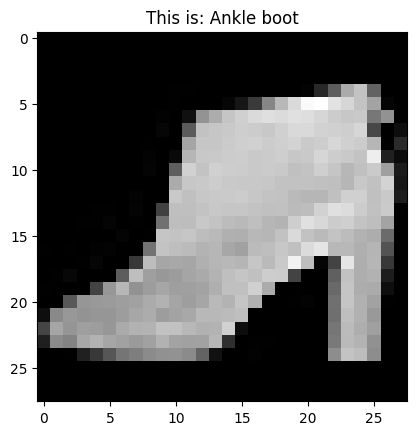

In [6]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [ ]:
def polynomial_kernel(X1, X2, degree=2, coef0=1.0, gamma=None):

    X1 = np.array(X1, dtype=np.float64)
    X2 = np.array(X2, dtype=np.float64)
    if gamma is None:
        gamma = 1.0 / X1.shape[1]
    return (gamma * X1 @ X2.T + coef0) ** degree


def rbf_kernel(X1, X2, gamma=None):
    X1 = np.array(X1, dtype=np.float64)
    X2 = np.array(X2, dtype=np.float64)
    if gamma is None:
        gamma = 1.0 / X1.shape[1]
    sq1 = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
    sq2 = np.sum(X2 ** 2, axis=1).reshape(1, -1)
    dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
    dist_sq = np.maximum(dist_sq, 0.0)  # numerical safety
    return np.exp(-gamma * dist_sq)


# Default nonlinear kernel — use RBF which is numerically stable
def nonlinear_kernel(X1, X2):
    """Default nonlinear kernel (RBF with auto gamma)."""
    return rbf_kernel(X1, X2)


In [ ]:
class SVM(object):

    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        """
        Initialize SVM.
        kernel : callable(X1, X2) -> kernel matrix
        C : regularization parameter (higher = less regularization)
        """
        self.kernel = kernel
        self.C = C

    def fit(self, X, y):
        """
        Fit SVM via the dual QP formulation using cvxopt.
        
        Dual problem (Bishop 7.32 reformulated for cvxopt minimization):
          minimize   (1/2) a^T (T K T) a  -  1^T a
          subject to   0 <= a_i <= C
                        t^T a = 0
        """
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).flatten()
        n = X.shape[0]

        # Step 1: Compute kernel matrix
        K = self.kernel(X, X)

        # Step 2: Build QP matrices
        # P = T K T  where T_ij = t_i * t_j (outer product of labels)
        P = np.outer(y, y) * K
        P = P + 1e-7 * np.eye(n)  # ensure positive semi-definiteness

        P_cvx = matrix(P, tc='d')
        q_cvx = matrix(-np.ones(n), tc='d')

        # Inequality: G a <= h  =>  [I; -I] a <= [C; 0]
        G = np.vstack([np.eye(n), -np.eye(n)])
        h = np.hstack([self.C * np.ones(n), np.zeros(n)])
        G_cvx = matrix(G, tc='d')
        h_cvx = matrix(h, tc='d')

        # Equality: t^T a = 0
        A_cvx = matrix(y.reshape(1, -1), tc='d')
        b_cvx = matrix(np.zeros(1), tc='d')

        # Step 3: Solve
        sol = cvxopt.solvers.qp(P_cvx, q_cvx, G_cvx, h_cvx, A_cvx, b_cvx)
        alphas = np.array(sol['x']).flatten()

        # Step 4: Extract support vectors (alpha > threshold)
        sv_thr = 1e-5
        sv_mask = alphas > sv_thr
        self.alphas = alphas[sv_mask]
        self.support_vectors = X[sv_mask]
        self.support_labels = y[sv_mask]

        # Step 5: Compute bias b (Bishop eq. 7.37)
        # Use "free" support vectors: sv_thr < alpha < C - sv_thr
        free_mask = (alphas > sv_thr) & (alphas < self.C - sv_thr)
        if np.sum(free_mask) > 0:
            free_idx = np.where(free_mask)[0]
            b_vals = []
            for idx in free_idx:
                K_col = self.kernel(self.support_vectors, X[idx:idx+1]).flatten()
                b_val = y[idx] - np.sum(self.alphas * self.support_labels * K_col)
                b_vals.append(b_val)
            self.b = np.mean(b_vals)
        else:
            # Fallback: use all support vectors
            sv_idx = np.where(sv_mask)[0]
            b_vals = []
            for i, idx in enumerate(sv_idx):
                K_col = self.kernel(self.support_vectors, X[idx:idx+1]).flatten()
                b_val = y[idx] - np.sum(self.alphas * self.support_labels * K_col)
                b_vals.append(b_val)
            self.b = np.mean(b_vals)

        return self

    def decision_function(self, X):
       
        X = np.array(X, dtype=np.float64)
        K = self.kernel(self.support_vectors, X)  # (n_sv, n_test)
        return (self.alphas * self.support_labels) @ K + self.b

    def predict(self, X):
       
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        
        y_pred = self.predict(X)
        return np.mean(y_pred == np.array(y).flatten())


## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [9]:
## ===== Feature Scaling =====
from sklearn.preprocessing import MinMaxScaler

# Scale pixel values to [0, 1] — critical for kernel methods
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train_samples)
X_test_scaled = scaler.transform(test_samples)

## ===== One-vs-Rest (OvR) Multiclass SVM =====
class OneVsRestSVM:
    """Train one binary SVM per class (class vs all others). Predict by max decision value."""
    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        self.kernel = kernel
        self.C = C
        self.classifiers = {}
        self.classes = None

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y).flatten()
        self.classes = np.unique(y)
        for cls in self.classes:
            print(f"  OvR: training class {cls} ({label_to_title.get(cls, cls)}) vs rest...")
            y_bin = np.where(y == cls, 1.0, -1.0)
            svm = SVM(kernel=self.kernel, C=self.C)
            svm.fit(X, y_bin)
            self.classifiers[cls] = svm
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        dec = np.zeros((X.shape[0], len(self.classes)))
        for i, cls in enumerate(self.classes):
            dec[:, i] = self.classifiers[cls].decision_function(X)
        return self.classes[np.argmax(dec, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y).flatten())


In [10]:
## ===== One-vs-One (OvO) Multiclass SVM =====
from itertools import combinations

class OneVsOneSVM:
    """Train one binary SVM per class pair. Predict by majority vote."""
    def __init__(self, kernel=nonlinear_kernel, C=1.0):
        self.kernel = kernel
        self.C = C
        self.classifiers = {}
        self.classes = None

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y).flatten()
        self.classes = np.unique(y)
        for ci, cj in combinations(self.classes, 2):
            print(f"  OvO: class {ci} vs class {cj}...")
            mask = (y == ci) | (y == cj)
            X_pair = X[mask]
            y_pair = np.where(y[mask] == ci, 1.0, -1.0)
            svm = SVM(kernel=self.kernel, C=self.C)
            svm.fit(X_pair, y_pair)
            self.classifiers[(ci, cj)] = svm
        return self

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        n = X.shape[0]
        votes = np.zeros((n, len(self.classes)))
        cls2idx = {c: i for i, c in enumerate(self.classes)}
        for (ci, cj), svm in self.classifiers.items():
            preds = svm.predict(X)
            for s in range(n):
                if preds[s] >= 0:
                    votes[s, cls2idx[ci]] += 1
                else:
                    votes[s, cls2idx[cj]] += 1
        return self.classes[np.argmax(votes, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y).flatten())


## ===== Train & Compare =====
C_val = 10.0
kernel_fn = lambda X1, X2: rbf_kernel(X1, X2)

print("=== Training One-vs-Rest (OvR) ===")
ovr = OneVsRestSVM(kernel=kernel_fn, C=C_val)
ovr.fit(X_train_scaled, train_samples_labels)
ovr_train = ovr.score(X_train_scaled, train_samples_labels)
ovr_test = ovr.score(X_test_scaled, test_samples_labels)
print(f"OvR — Train: {ovr_train:.4f}, Test: {ovr_test:.4f}\n")

print("=== Training One-vs-One (OvO) ===")
ovo = OneVsOneSVM(kernel=kernel_fn, C=C_val)
ovo.fit(X_train_scaled, train_samples_labels)
ovo_train = ovo.score(X_train_scaled, train_samples_labels)
ovo_test = ovo.score(X_test_scaled, test_samples_labels)
print(f"OvO — Train: {ovo_train:.4f}, Test: {ovo_test:.4f}\n")

print("=== Comparison ===")
print(f"{'Method':<10} {'Train Acc':>10} {'Test Acc':>10}")
print(f"{'OvR':<10} {ovr_train:>10.4f} {ovr_test:>10.4f}")
print(f"{'OvO':<10} {ovo_train:>10.4f} {ovo_test:>10.4f}")


=== Training One-vs-Rest (OvR) ===
  OvR: training class 0 (T-shirt/top) vs rest...


/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: divide by zero encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: overflow encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: invalid value encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)


  OvR: training class 1 (Trouser) vs rest...
  OvR: training class 2 (Pullover) vs rest...
  OvR: training class 3 (Dress) vs rest...
  OvR: training class 4 (Coat) vs rest...
  OvR: training class 5 (Sandal) vs rest...
  OvR: training class 6 (Shirt) vs rest...
  OvR: training class 7 (Sneaker) vs rest...
  OvR: training class 8 (Bag) vs rest...
  OvR: training class 9 (Ankle boot) vs rest...


/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: divide by zero encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: overflow encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: invalid value encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b


OvR — Train: 0.8956, Test: 0.8350

=== Training One-vs-One (OvO) ===
  OvO: class 0 vs class 1...
  OvO: class 0 vs class 2...
  OvO: class 0 vs class 3...
  OvO: class 0 vs class 4...
  OvO: class 0 vs class 5...
  OvO: class 0 vs class 6...
  OvO: class 0 vs class 7...
  OvO: class 0 vs class 8...
  OvO: class 0 vs class 9...
  OvO: class 1 vs class 2...
  OvO: class 1 vs class 3...
  OvO: class 1 vs class 4...
  OvO: class 1 vs class 5...
  OvO: class 1 vs class 6...
  OvO: class 1 vs class 7...
  OvO: class 1 vs class 8...
  OvO: class 1 vs class 9...
  OvO: class 2 vs class 3...
  OvO: class 2 vs class 4...
  OvO: class 2 vs class 5...
  OvO: class 2 vs class 6...
  OvO: class 2 vs class 7...
  OvO: class 2 vs class 8...
  OvO: class 2 vs class 9...
  OvO: class 3 vs class 4...
  OvO: class 3 vs class 5...
  OvO: class 3 vs class 6...
  OvO: class 3 vs class 7...
  OvO: class 3 vs class 8...
  OvO: class 3 vs class 9...
  OvO: class 4 vs class 5...
  OvO: class 4 vs class 6...
  O

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

Testing C values: [   1.      5.62   31.62  177.83 1000.  ]

C = 1.00 ...
  OvO: class 0 vs class 1...
  OvO: class 0 vs class 2...
  OvO: class 0 vs class 3...
  OvO: class 0 vs class 4...
  OvO: class 0 vs class 5...
  OvO: class 0 vs class 6...
  OvO: class 0 vs class 7...
  OvO: class 0 vs class 8...
  OvO: class 0 vs class 9...
  OvO: class 1 vs class 2...
  OvO: class 1 vs class 3...
  OvO: class 1 vs class 4...
  OvO: class 1 vs class 5...
  OvO: class 1 vs class 6...


/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: divide by zero encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: overflow encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: invalid value encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)


  OvO: class 1 vs class 7...
  OvO: class 1 vs class 8...
  OvO: class 1 vs class 9...
  OvO: class 2 vs class 3...
  OvO: class 2 vs class 4...
  OvO: class 2 vs class 5...
  OvO: class 2 vs class 6...
  OvO: class 2 vs class 7...
  OvO: class 2 vs class 8...
  OvO: class 2 vs class 9...
  OvO: class 3 vs class 4...
  OvO: class 3 vs class 5...
  OvO: class 3 vs class 6...
  OvO: class 3 vs class 7...
  OvO: class 3 vs class 8...
  OvO: class 3 vs class 9...
  OvO: class 4 vs class 5...
  OvO: class 4 vs class 6...
  OvO: class 4 vs class 7...
  OvO: class 4 vs class 8...
  OvO: class 4 vs class 9...
  OvO: class 5 vs class 6...
  OvO: class 5 vs class 7...
  OvO: class 5 vs class 8...
  OvO: class 5 vs class 9...
  OvO: class 6 vs class 7...
  OvO: class 6 vs class 8...
  OvO: class 6 vs class 9...
  OvO: class 7 vs class 8...
  OvO: class 7 vs class 9...
  OvO: class 8 vs class 9...


/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: divide by zero encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: overflow encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: invalid value encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b


  Train: 0.7811, Test: 0.7900

C = 5.62 ...
  OvO: class 0 vs class 1...
  OvO: class 0 vs class 2...
  OvO: class 0 vs class 3...
  OvO: class 0 vs class 4...
  OvO: class 0 vs class 5...
  OvO: class 0 vs class 6...
  OvO: class 0 vs class 7...
  OvO: class 0 vs class 8...
  OvO: class 0 vs class 9...
  OvO: class 1 vs class 2...
  OvO: class 1 vs class 3...
  OvO: class 1 vs class 4...
  OvO: class 1 vs class 5...
  OvO: class 1 vs class 6...
  OvO: class 1 vs class 7...
  OvO: class 1 vs class 8...
  OvO: class 1 vs class 9...
  OvO: class 2 vs class 3...
  OvO: class 2 vs class 4...
  OvO: class 2 vs class 5...
  OvO: class 2 vs class 6...
  OvO: class 2 vs class 7...
  OvO: class 2 vs class 8...
  OvO: class 2 vs class 9...
  OvO: class 3 vs class 4...
  OvO: class 3 vs class 5...
  OvO: class 3 vs class 6...
  OvO: class 3 vs class 7...
  OvO: class 3 vs class 8...
  OvO: class 3 vs class 9...
  OvO: class 4 vs class 5...
  OvO: class 4 vs class 6...
  OvO: class 4 vs class 7...

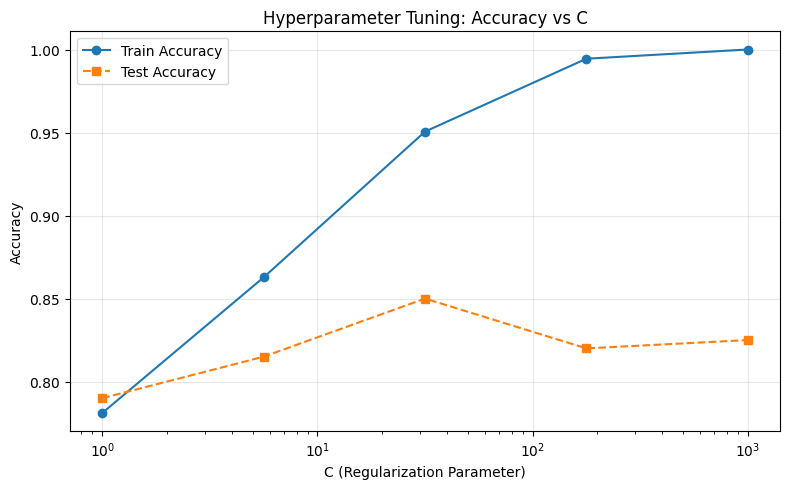


Best C = 31.62 with Test Accuracy = 0.8500


In [11]:
## ===== Task 4: Hyperparameter Tuning for C =====
C_values = np.logspace(0, 3, 5)  # [1, 5.6, 31.6, 177.8, 1000]
print("Testing C values:", np.round(C_values, 2))

results = []
for C_test in C_values:
    print(f"\nC = {C_test:.2f} ...")
    model = OneVsOneSVM(kernel=lambda X1, X2: rbf_kernel(X1, X2), C=C_test)
    model.fit(X_train_scaled, train_samples_labels)
    tr = model.score(X_train_scaled, train_samples_labels)
    te = model.score(X_test_scaled, test_samples_labels)
    results.append((C_test, tr, te))
    print(f"  Train: {tr:.4f}, Test: {te:.4f}")

Cs = [r[0] for r in results]
tr_accs = [r[1] for r in results]
te_accs = [r[2] for r in results]

plt.figure(figsize=(8, 5))
plt.semilogx(Cs, tr_accs, 'o-', label='Train Accuracy')
plt.semilogx(Cs, te_accs, 's--', label='Test Accuracy')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Accuracy')
plt.title('Hyperparameter Tuning: Accuracy vs C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(te_accs)
best_C = Cs[best_idx]
print(f"\nBest C = {best_C:.2f} with Test Accuracy = {te_accs[best_idx]:.4f}")


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [12]:
## ===== Task 5: Confusion Matrix =====
print(f"Training final model with best C = {best_C:.2f} ...")
final_model = OneVsOneSVM(kernel=lambda X1, X2: rbf_kernel(X1, X2), C=best_C)
final_model.fit(X_train_scaled, train_samples_labels)

predictions = final_model.predict(X_test_scaled)
final_acc = np.mean(predictions == test_samples_labels)
print(f"Final Test Accuracy: {final_acc:.4f}")


Training final model with best C = 31.62 ...
  OvO: class 0 vs class 1...
  OvO: class 0 vs class 2...
  OvO: class 0 vs class 3...
  OvO: class 0 vs class 4...
  OvO: class 0 vs class 5...
  OvO: class 0 vs class 6...
  OvO: class 0 vs class 7...
  OvO: class 0 vs class 8...
  OvO: class 0 vs class 9...
  OvO: class 1 vs class 2...
  OvO: class 1 vs class 3...


/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: divide by zero encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: overflow encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/1284810689.py:24: RuntimeWarning: invalid value encountered in matmul
  dist_sq = sq1 + sq2 - 2.0 * (X1 @ X2.T)


  OvO: class 1 vs class 4...
  OvO: class 1 vs class 5...
  OvO: class 1 vs class 6...
  OvO: class 1 vs class 7...
  OvO: class 1 vs class 8...
  OvO: class 1 vs class 9...
  OvO: class 2 vs class 3...
  OvO: class 2 vs class 4...
  OvO: class 2 vs class 5...
  OvO: class 2 vs class 6...
  OvO: class 2 vs class 7...
  OvO: class 2 vs class 8...
  OvO: class 2 vs class 9...
  OvO: class 3 vs class 4...
  OvO: class 3 vs class 5...
  OvO: class 3 vs class 6...
  OvO: class 3 vs class 7...
  OvO: class 3 vs class 8...
  OvO: class 3 vs class 9...
  OvO: class 4 vs class 5...
  OvO: class 4 vs class 6...
  OvO: class 4 vs class 7...
  OvO: class 4 vs class 8...
  OvO: class 4 vs class 9...
  OvO: class 5 vs class 6...
  OvO: class 5 vs class 7...
  OvO: class 5 vs class 8...
  OvO: class 5 vs class 9...
  OvO: class 6 vs class 7...
  OvO: class 6 vs class 8...
  OvO: class 6 vs class 9...
  OvO: class 7 vs class 8...
  OvO: class 7 vs class 9...
  OvO: class 8 vs class 9...
Final Test Acc

/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: divide by zero encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: overflow encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b
/var/folders/ry/s304r8gd7wqd6yrrmfjn4v0h0000gn/T/ipykernel_5620/2458973176.py:84: RuntimeWarning: invalid value encountered in matmul
  return (self.alphas * self.support_labels) @ K + self.b


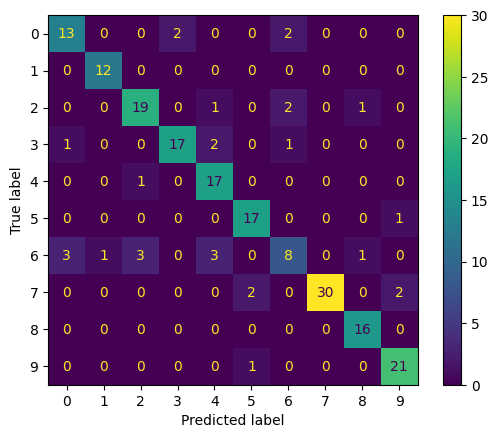

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.